# 📩 SMS Spam Detection using Machine Learning

## Problem Statement
SMS spam messages are a common problem that can lead to fraud, phishing, and unwanted advertisements. The goal of this project is to build a machine learning model that can automatically classify SMS messages as **Spam** or **Ham (Not Spam)**.

## Import Libraries

In [1]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# NLP Libraries
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('punkt')
nltk.download('stopwords')

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder

# Vectorizers
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Models
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Model Saving
import pickle

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Load Dataset 

In [2]:
df = pd.read_csv('../dataset/spam.csv',encoding='latin-1')

In [3]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


## EDA & Data Cleaning

In [4]:
# Checking shape of the dataset (rows and columns)
print(f"Number of rows : {df.shape[0]}")
print(f"Number of columns : {df.shape[1]}")

Number of rows : 5572
Number of columns : 5


In [5]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [6]:
# Checking missing values
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [7]:
# Checking duplicated values 
df.duplicated().sum()

np.int64(403)

### Observation : 
- Total number of rows are **5572**
- Total number of columns are **5** 
- There are **missing values** in the dataset, but are in unwanted columns only
- Total number of duplicated values are **403**
- [**Unnamed: 2, Unnamed: 3, Unnamed: 4**] these are the unwanted features, need to be removed from dataset

In [8]:
# Removing unnecessary columns
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [9]:
# Re-checking dataset 
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


**Defining features name - Target and Message**

In [10]:
# Renaming features
df.rename(columns={'v1':'target','v2':'message'},inplace=True)

In [11]:
# Re-checking dataset 
df.head()

,target,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [12]:
# Re-checking missing values 
df.isnull().sum()

target     0
message    0
dtype: int64

In [13]:
# Droping dupicated values 
df = df.drop_duplicates(keep='first')

In [14]:
# Re-checking duplicated values 
df.duplicated().sum()

np.int64(0)

In [15]:
df['target'].value_counts()

target
ham     4516
spam     653
Name: count, dtype: int64

In [16]:
df['target'].unique()

array(['ham', 'spam'], dtype=object)

### Data Visualization 

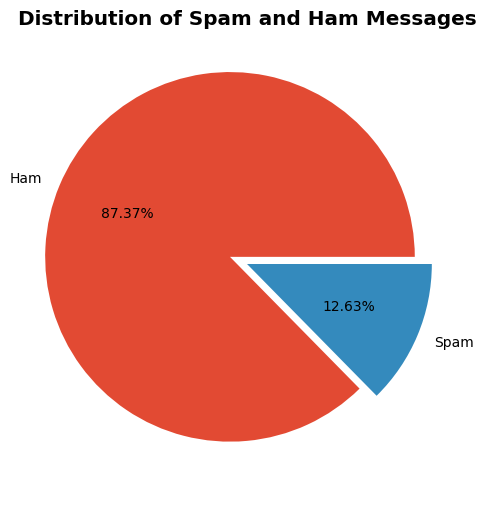

In [17]:
plt.figure(figsize=(6,6))
plt.style.use('ggplot')
plt.pie(df['target'].value_counts(),labels=['Ham','Spam'],autopct='%0.2f%%',explode=[0.1,0])
plt.title("Distribution of Spam and Ham Messages",fontweight='bold')
plt.show()

## Feature Engineering
Create features such as:
- total_characters
- total_words
- total_sentences

In [18]:
# Creating total_characters column 
df['total_characters'] = df['message'].apply(len)

# Creating total_words column 
df['total_words'] = df['message'].apply(lambda x: len(nltk.word_tokenize(x)))

# Creating total_sentences column 
df['total_sentences'] = df['message'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [19]:
df.head()

,target,message,total_characters,total_words,total_sentences
0,ham,"Go until jurong point, crazy.. Available only ...",111,24,2
1,ham,Ok lar... Joking wif u oni...,29,8,2
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,ham,U dun say so early hor... U c already then say...,49,13,1
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15,1


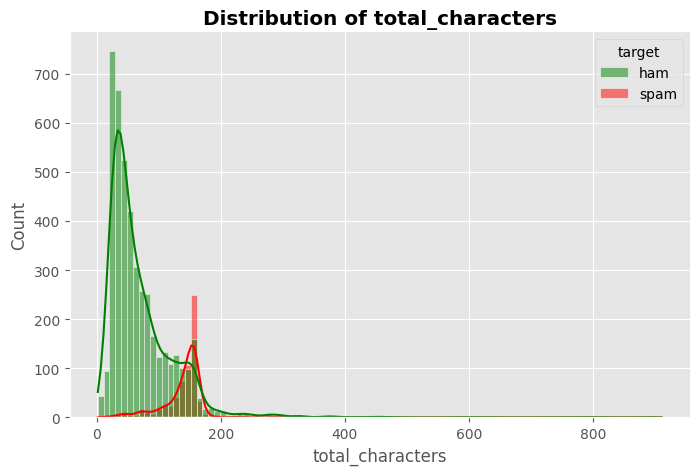

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='total_characters',kde=True,hue='target',palette={'ham':'green','spam':'red'})
plt.title('Distribution of total_characters', fontweight='bold')
sns.despine()
plt.show()

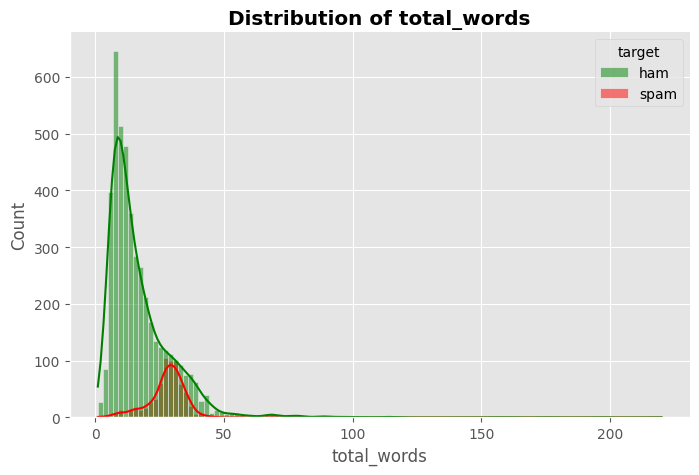

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='total_words',kde=True,hue='target',palette={'ham':'green','spam':'red'})
plt.title('Distribution of total_words', fontweight='bold')
sns.despine()
plt.show()

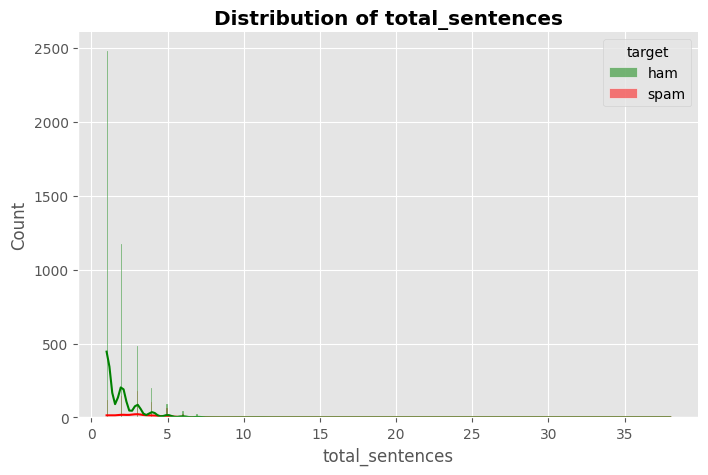

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='total_sentences',kde=True,hue='target',palette={'ham':'green','spam':'red'})
plt.title('Distribution of total_sentences', fontweight='bold')
sns.despine()
plt.show()

<Axes: >

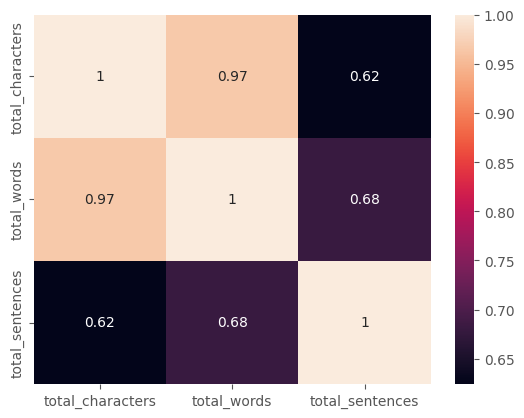

In [23]:
sns.heatmap(df.select_dtypes(include='number').corr(),annot = True)

In [24]:
num_cols = [col for col in df.columns if df[col].dtype != 'O']

In [25]:
num_cols

['total_characters', 'total_words', 'total_sentences']

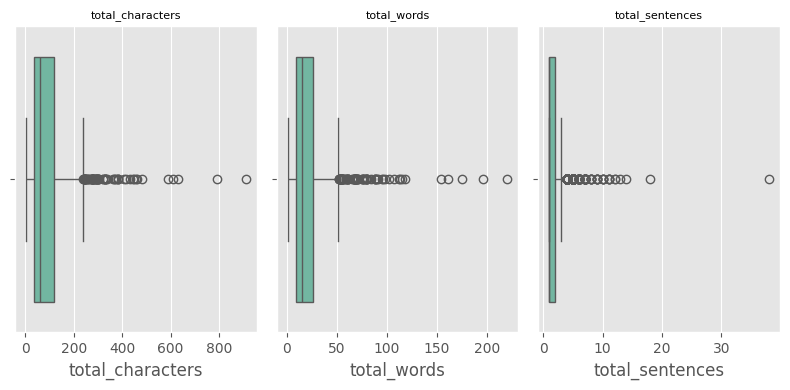

In [26]:
# Checking outliers
fig, axes = plt.subplots(1,3,figsize=(8,4))
axes = axes.flatten() 

for i,col in enumerate(num_cols): 
    sns.boxplot(df[col],ax=axes[i],orient='h',palette="Set2")
    axes[i].set_title(col, fontsize=8)

plt.tight_layout()

## Encode Target Variable
Ham - 0  
Spam - 1

In [27]:
# Using label encoder 
encoder = LabelEncoder() 

df['target'] = encoder.fit_transform(df['target'])

In [28]:
df.head()

,target,message,total_characters,total_words,total_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


## Text Preprocessing 

In [29]:
# Defining Porter Stemmer 
ps = PorterStemmer() 

In [85]:
corpus = []

for text in df['message']:
    text = re.sub('[^a-zA-Z0-9]', ' ', text)
    text = text.lower()
    text = text.split()
    text = [ps.stem(word) for word in text if word not in stopwords.words('english')]
    text = ' '.join(text)
    corpus.append(text)

In [86]:
df['transformed_message'] = corpus

In [87]:
df.head()

,target,message,total_characters,total_words,total_sentences,transformed_message
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [88]:
# Creating wordcloud for ham and spam massages 
from wordcloud import WordCloud

wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

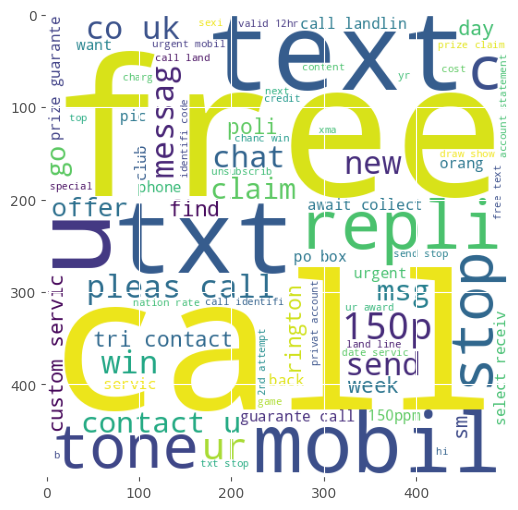

In [89]:
# Wordcloud for spam messages
spam_wc = wc.generate(df[df['target']==1]['transformed_message'].str.cat(sep=" "))
plt.figure(figsize=(8,6))
plt.imshow(spam_wc)
plt.show()

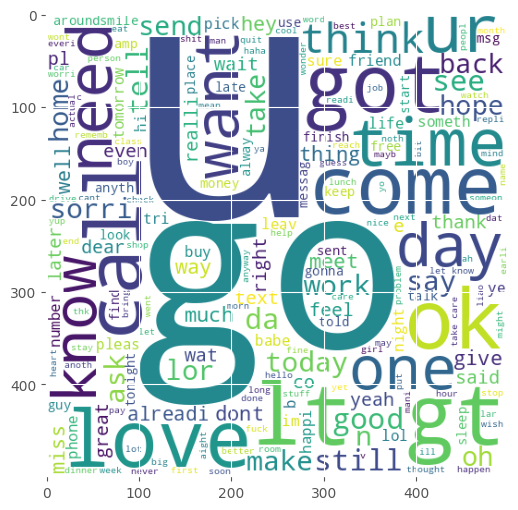

In [90]:
# wordcloud for ham messages
ham_wc = wc.generate(df[df['target']==0]['transformed_message'].str.cat(sep=" "))
plt.figure(figsize=(8,6))
plt.imshow(ham_wc)
plt.show()

**Top 30 words in spam and ham messages** 

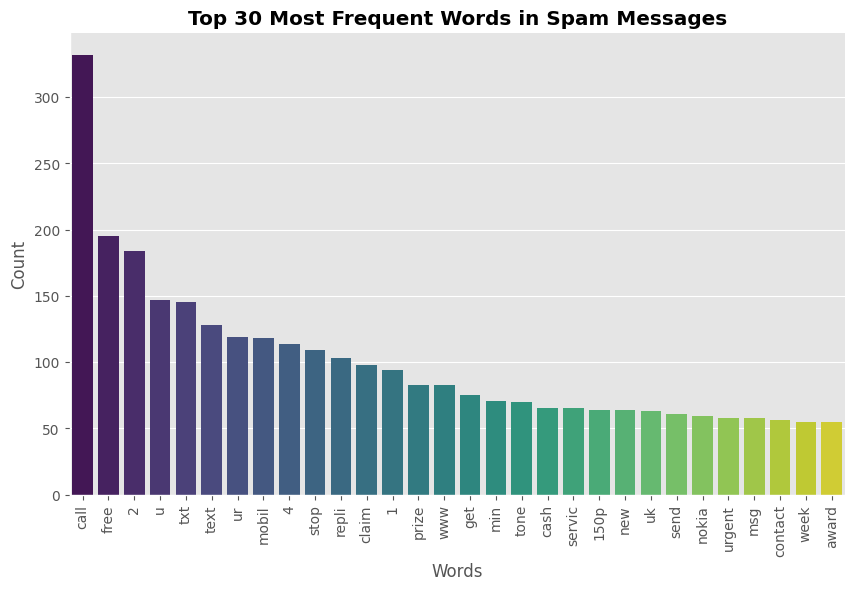

In [91]:
# Words in Spam messages 
spam_corpus = []
for msg in df[df['target']==1]['transformed_message'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

from collections import Counter 
top_spam_words = pd.DataFrame(Counter(spam_corpus).most_common(30))

plt.figure(figsize=(10,6))
sns.barplot(x=0, y=1, data=top_spam_words,palette='viridis')

plt.xticks(rotation=90)
plt.title("Top 30 Most Frequent Words in Spam Messages", fontweight='bold')
plt.xlabel("Words")
plt.ylabel("Count")

sns.despine()
plt.show()

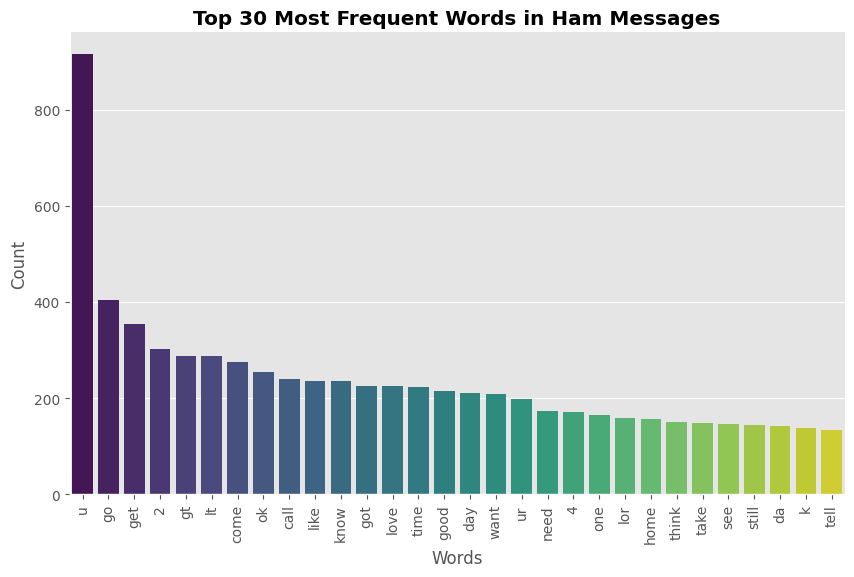

In [92]:
# Words in Ham messages 
ham_corpus = []
for msg in df[df['target']==0]['transformed_message'].tolist():
    for word in msg.split():
        ham_corpus.append(word)
        
from collections import Counter 
top_ham_words = pd.DataFrame(Counter(ham_corpus).most_common(30))

plt.figure(figsize=(10,6))
sns.barplot(x=0, y=1, data=top_ham_words,palette='viridis')

plt.xticks(rotation=90)
plt.title("Top 30 Most Frequent Words in Ham Messages", fontweight='bold')
plt.xlabel("Words")
plt.ylabel("Count")

sns.despine()
plt.show()

## Independent and Dependent features

In [93]:
# Separating dependent and independent features 
X = df['transformed_message'] # Independent features 
y = df['target'] # Dependent feature

In [94]:
X.head()

0    go jurong point crazi avail bugi n great world...
1                                ok lar joke wif u oni
2    free entri 2 wkli comp win fa cup final tkt 21...
3                  u dun say earli hor u c alreadi say
4                 nah think goe usf live around though
Name: transformed_message, dtype: object

In [95]:
y

0       0
1       0
2       1
3       0
4       0
       ..
5567    1
5568    0
5569    0
5570    0
5571    0
Name: target, Length: 5169, dtype: int64

# Train Test Split 

In [96]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape :", X_train.shape)
print("Test shape :", X_test.shape)

Train shape : (4135,)
Test shape : (1034,)


## Text Vectorization Pipeline 

In [97]:
vectorizer = TfidfVectorizer(
    max_features=7000, 
    ngram_range=(1,2), 
    sublinear_tf=True
)

## Model Selection & Evaluation

In [98]:
# Define models 
models = {
    "MultinomialNB": MultinomialNB(),
    "BernoulliNB": BernoulliNB(),
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "SVC": SVC(),
    "RandomForest": RandomForestClassifier()
}

# Creating function to evaluating model
def evaluate_model(true, predicted):

    acc = accuracy_score(true, predicted)
    prec = precision_score(true, predicted)
    rec = recall_score(true, predicted)
    f1 = f1_score(true, predicted)

    return acc, prec, rec, f1

results = []

for name, model in models.items():

    model_pipeline = Pipeline([
        ("vectorizer", vectorizer),
        ("model", model)
    ])

    model_pipeline.fit(X_train, y_train)

    y_train_pred = model_pipeline.predict(X_train)
    y_test_pred = model_pipeline.predict(X_test)

    train_acc, train_prec, train_rec, train_f1 = evaluate_model(y_train, y_train_pred)
    test_acc, test_prec, test_rec, test_f1 = evaluate_model(y_test, y_test_pred)

    print(f"========== {name} ==========")

    print("Train Performance")
    print("Accuracy:", train_acc)
    print("Precision:", train_prec)
    print("Recall:", train_rec)
    print("F1:", train_f1)

    print("-"*30)

    print("Test Performance")
    print("Accuracy:", test_acc)
    print("Precision:", test_prec)
    print("Recall:", test_rec)
    print("F1:", test_f1)
    
    print("\n")

    results.append({
        "Model": name,
        "Accuracy": test_acc,
        "Precision": test_prec,
        "Recall": test_rec, 
        "F1": test_f1
        
    })

========== MultinomialNB ==========
Train Performance
Accuracy: 0.9813784764207981
Precision: 1.0
Recall: 0.8524904214559387
F1: 0.9203722854188211
------------------------------
Test Performance
Accuracy: 0.9632495164410058
Precision: 1.0
Recall: 0.7099236641221374
F1: 0.8303571428571429


========== BernoulliNB ==========
Train Performance
Accuracy: 0.9806529625151149
Precision: 0.9977477477477478
Recall: 0.8486590038314177
F1: 0.917184265010352
------------------------------
Test Performance
Accuracy: 0.9671179883945842
Precision: 1.0
Recall: 0.7404580152671756
F1: 0.8508771929824561


========== LogisticRegression ==========
Train Performance
Accuracy: 0.9702539298669891
Precision: 0.9877750611246944
Recall: 0.7739463601532567
F1: 0.8678839957035446
------------------------------
Test Performance
Accuracy: 0.9661508704061895
Precision: 1.0
Recall: 0.732824427480916
F1: 0.8458149779735683


========== SVC ==========
Train Performance
Accuracy: 0.9966142684401451
Precision: 1.0
Recal

In [99]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by=["F1","Accuracy"], ascending=False)

results_df

,Model,Accuracy,Precision,Recall,F1
3,SVC,0.979691,1.000000,0.839695,0.912863
4,RandomForest,0.974855,0.981651,0.816794,0.891667
1,BernoulliNB,0.967118,1.000000,0.740458,0.850877
2,LogisticRegression,0.966151,1.000000,0.732824,0.845815
0,MultinomialNB,0.963250,1.000000,0.709924,0.830357


In [100]:
best_model = results_df.iloc[0]

print("Best Model :", best_model["Model"])
print("Accuracy :", f"{best_model['Accuracy']:.4f}")
print("Precision :", f"{best_model['Precision']:.4f}") 
print("F1 :", f"{best_model['F1']:.4f}") 
print("Recall:", f"{best_model['Recall']:.4f}") 

Best Model : SVC
Accuracy : 0.9797
Precision : 1.0000
F1 : 0.9129
Recall: 0.8397


## Hyperparameter Tuning

In [101]:
# Creating pipeline fot SVC() 
svc_pipeline = Pipeline([
    ("vectorizer", TfidfVectorizer()),
    ("model", SVC(class_weight="balanced"))
])

In [102]:
# Initializing parameters for hyperparamter tuning
params = {

    "vectorizer__max_features":[3000,5000,7000],
    
    "vectorizer__ngram_range":[(1,1),(1,2)],
    
    "model__C":[0.1,1,10],
    
    "model__kernel":["linear","rbf"]

}

In [103]:
# Hyperparameter tuning using GridSearchCV 

grid = GridSearchCV(
    svc_pipeline,
    param_grid=params,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train,y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


,estimator,Pipeline(step...'balanced'))])
,param_grid,"{'model__C': [0.1, 1, ...], 'model__kernel': ['linear', 'rbf'], 'vectorizer__max_features': [3000, 5000, ...], 'vectorizer__ngram_range': [(1, ...), (1, ...)]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,input,'content'


In [104]:
print("==== Best Score and Params ====")
print("Best Score:",grid.best_score_)
print("Best Params :",grid.best_params_)
print("\n")
best_model = grid.best_estimator_
print(best_model)

==== Best Score and Params ====
Best Score: 0.9353442298074695
Best Params : {'model__C': 10, 'model__kernel': 'linear', 'vectorizer__max_features': 7000, 'vectorizer__ngram_range': (1, 2)}


Pipeline(steps=[('vectorizer',
                 TfidfVectorizer(max_features=7000, ngram_range=(1, 2))),
                ('model', SVC(C=10, class_weight='balanced', kernel='linear'))])


## Final Model Evaluation

In [105]:
y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test,y_pred))
print("Precision:", precision_score(y_test,y_pred))
print("Recall:", recall_score(y_test, y_pred)) 
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.9816247582205029
Precision: 0.9590163934426229
Recall: 0.8931297709923665
F1 Score: 0.924901185770751


In [106]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[898   5]
 [ 14 117]]


In [107]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       903
           1       0.96      0.89      0.92       131

    accuracy                           0.98      1034
   macro avg       0.97      0.94      0.96      1034
weighted avg       0.98      0.98      0.98      1034



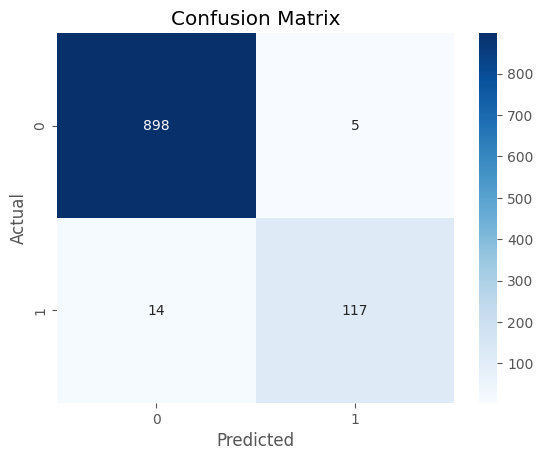

In [108]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,y_pred)

sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Prediction 

In [109]:
test_msgs = [
    "WIN cash prize now",
    "Heyy bro, are we meeting today ?",
    "URGENT! claim your reward",
    "Call this number to claim prize",
    "You have won a lottery prize"
    ]

pred = best_model.predict(test_msgs)

for msg,p in zip(test_msgs,pred):
    
    if p==1:
        print(f"SPAM: {msg}")
    else:
        print(f"HAM: {msg}")

SPAM: WIN cash prize now
HAM: Heyy bro, are we meeting today ?
SPAM: URGENT! claim your reward
SPAM: Call this number to claim prize
SPAM: You have won a lottery prize


## Save the Model

In [110]:
pickle.dump(best_model, open("../model/model.pkl", "wb"))

In [111]:
model = pickle.load(open("../model/model.pkl","rb"))

model.predict(["Are you coming ?"])

array([0])